# GW parameter estimation with PTMCMC

We use the IMRPhenomD $h_{22}$ waveform model to simulate (noise-free) data and recover the parameters via parallel tempering MCMC. The noise weighted inner product uses the aLIGO theoretical noise PSD. All inner products, likelihood evaluations, etc. are conducted in the frequency-domain.

5/25/26-6/1/26 ~ Edits are to include a SINGLE "no-tail" PTMCMC analysis, where the TaylorF2 explicit log term(s) are completely suppressed (lambda=1) for the purpose of calculating a Bayes factor.
    5/25: traced data flow of log coeffs, now I'm ready to build code that calculates suppression terms
    5/26: Embedded suppression into existing data flow for top-down control of log terms, produced plots of log-suppressed TD and FD waveforms
    5/29: Ran first no-log PTMCMC, ran a few diagnostics (1-(h_i|h_j), \Delta\Psi(f))
    5/30: Fixed lack of log suppression in the connection coefficients portion of the data flow
    6/1: Ran second no-log PTMCMC
    

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from corner import corner
from scipy.stats import multivariate_normal

import wave_gen as wg
import data as d
import likelihood as l
import jumps as j
from PTMCMC import PTMCMC


Inputted toggling scales: lambda15 = 1, lambda25 = 0, lambda3 = 0, lambda35 = 0


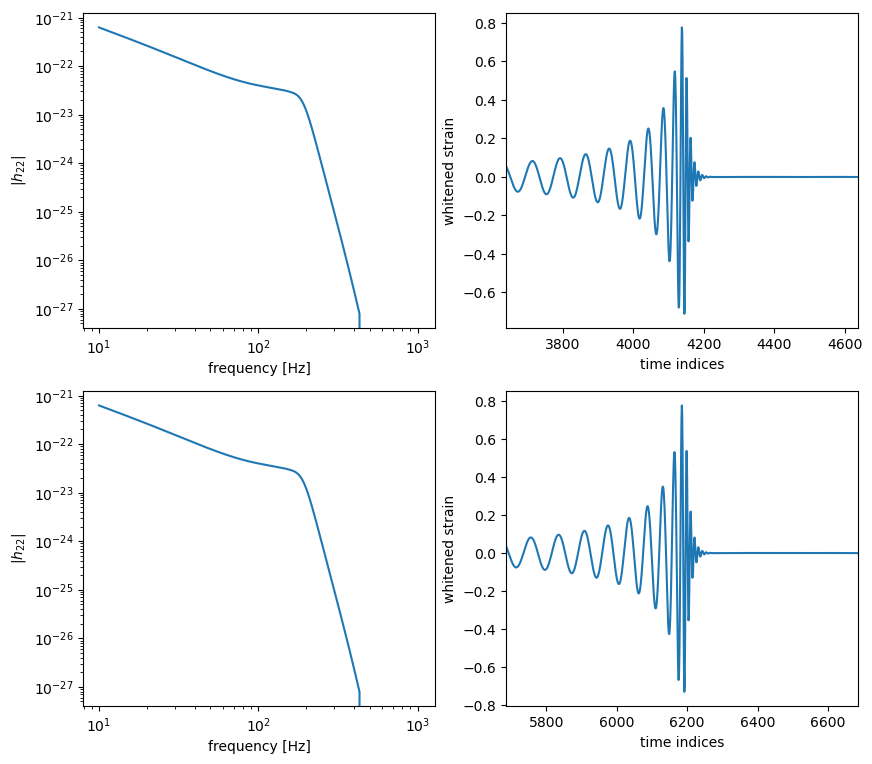

In [2]:
# plot injected waveforms (data) in frequency- and time-domain

## frequency-domain
print('Inputted toggling scales: lambda15 = {}, lambda25 = {}, lambda3 = {}, lambda35 = {}'.format(d.lambda15, d.lambda25, d.lambda3, d.lambda35))
plt.figure(figsize=(10, 9))

# logs (default)
plt.subplot(2, 2, 1)
plt.loglog(wg.f, d.data_amp)
plt.xlabel('frequency [Hz]')
plt.ylabel(r'$|h_{22}|$')

# no logs (arbitrary suppression)
plt.subplot(2, 2, 3)
plt.loglog(wg.f, d.data_amp_suppressed)
plt.xlabel('frequency [Hz]')
plt.ylabel(r'$|h_{22}|$')

## time-domain

# logs
plt.subplot(2, 2, 2)
#pad lower frequencies for iFFT
npad = int(wg.f[0] / wg.df)
whitened_FD_waveform = np.pad(d.data_FD_waveform / l.sqrtS, (npad, 0))
TD_waveform = np.fft.irfft(whitened_FD_waveform)
TD_waveform = np.roll(TD_waveform, TD_waveform.shape[0] // 2)
plt.plot(TD_waveform)
plt.xlim(np.argmax(TD_waveform) - 500, np.argmax(TD_waveform) + 500)
plt.xlabel('time indices')
plt.ylabel('whitened strain')

# no logs
plt.subplot(2, 2, 4)
# pad lower frequencies for iFFT
npad = int(wg.f[0] / wg.df)
whitened_FD_waveform_suppressed = np.pad(d.data_FD_waveform_suppressed / l.sqrtS, (npad, 0))
TD_waveform_suppressed = np.fft.irfft(whitened_FD_waveform_suppressed)
TD_waveform_suppressed = np.roll(TD_waveform_suppressed, TD_waveform_suppressed.shape[0] // 2)
plt.plot(TD_waveform_suppressed)
plt.xlim(np.argmax(TD_waveform_suppressed) - 500, np.argmax(TD_waveform_suppressed) + 500)
#plt.xlim(3600,6400)
plt.xlabel('time indices')
plt.ylabel('whitened strain')
plt.show()

Mismatch metric 1-(h_log|h_nolog) =
1.326701610720737
Mismatch metric (h_log-h_nolog | h_log-h_nolog) =
154525.0203372036
$\Delta\Psi$ Slope: 6.283185307179587


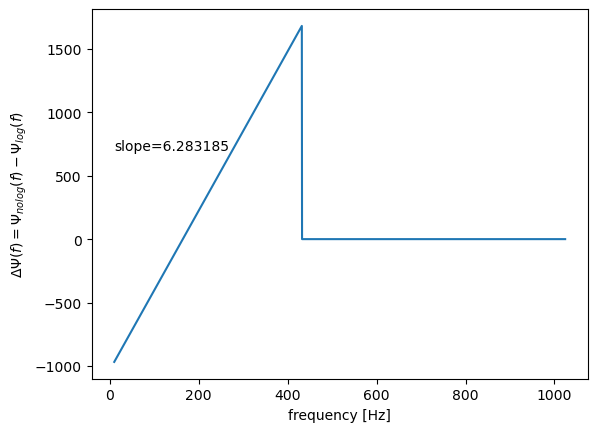

In [3]:
# Calculate mismatch between the two waveforms
print('Mismatch metric 1-(h_log|h_nolog) =')
print(1-l.inner(d.data_FD_waveform, d.data_FD_waveform_suppressed))
print('Mismatch metric (h_log-h_nolog | h_log-h_nolog) =')
print(l.inner(d.data_FD_waveform-d.data_FD_waveform_suppressed,
              d.data_FD_waveform-d.data_FD_waveform_suppressed))



# Analyse phase differences between the two waveforms (log vs no log)
delta_psi = d.data_phase_suppressed - d.data_phase

delta_psi_max, delta_psi_min = np.max(delta_psi), np.min(delta_psi)
f_max_i, f_min_i = np.argmax(delta_psi), np.argmin(delta_psi)
slope = (delta_psi_max - delta_psi_min) / (wg.f[f_max_i] - wg.f[f_min_i])
print('$\Delta\Psi$ Slope: {}'.format(slope))

plt.plot(wg.f,delta_psi)
plt.xlabel('frequency [Hz]')
plt.ylabel(r'$\Delta\Psi(f)=\Psi_{nolog}(f)-\Psi_{log}(f)$')
plt.annotate('slope='+str(round(slope,6)), xy=(10, 700), xytext=(10, 700))
#plt.annotate('$2\pi t_c$='+str(round(2*np.pi* * * * tc * * *,2)), xy=(700,500), xytext=(700,500))

plt.show()

# Plot \Psi'_{no log}(f)-\Psi'_{log}(f) to see if it is constant (as expected from the phase difference being linear in frequency)


In [4]:
# jump proposals
Fisher = j.Fisher(d.x_inj)
Fisher_suppressed = j.Fisher(d.x_inj, lambda15=d.lambda15, lambda25=d.lambda25, lambda3=d.lambda3, lambda35=d.lambda35)

diff_evol = j.DifferentialEvolution(len_history=100)
jump_proposals = [[Fisher.vectorized_Fisher_jump, 20],
                  [diff_evol.vectorized_DE_jump, 20]]
jump_proposals_suppressed = [[Fisher_suppressed.vectorized_Fisher_jump, 20],
                  [diff_evol.vectorized_DE_jump, 20]]


# do PTMCMC with logs!
num_samples = int(1e5)
num_chains = 15

samples, lnposts, temp_ladder = PTMCMC(num_samples=num_samples,
                                       num_chains=num_chains,
                                       x0=d.x_inj,
                                       ln_posterior_func=l.ln_posterior,
                                       jump_proposals=jump_proposals,
                                       PT_swap_weight=10)

# do PTMCMC again with no logs!
samples_suppressed, lnposts_suppressed, temp_ladder_suppressed = PTMCMC(num_samples=num_samples,
                                       num_chains=num_chains,
                                       x0=d.x_inj,
                                       ln_posterior_func=l.ln_posterior,
                                       jump_proposals=jump_proposals_suppressed,
                                       PT_swap_weight=10,
                                       lambda15=d.lambda15, lambda25=d.lambda25, lambda3=d.lambda3, lambda35=d.lambda35)

Jump acceptance rates
Fisher_jump: [0.69018544 0.68699432 0.68196894 0.67455651 0.67412935 0.66777225
 0.66159103 0.65621388 0.65297251 0.64724358 0.64088648 0.63719282
 0.62606161 0.62641339 0.62138801]
DE_jump: [0.00957725 0.00970196 0.00975184 0.01057488 0.01037536 0.01064971
 0.01172216 0.01082429 0.01122334 0.01169722 0.01144781 0.01212121
 0.01369248 0.01281955 0.01346801]
PT_swap: [0.75171591 0.758679   0.75753506 0.75723665 0.76037004 0.75609271
 0.75678902 0.75838058 0.75261116 0.74972645 0.7495275  0.74768726
 0.75624192 0.75460062 0.        ]
Jump acceptance rates
Fisher_jump: [0.59952494 0.59377422 0.58997375 0.58307288 0.58032254 0.57634704
 0.57482185 0.56824603 0.56662083 0.5655707  0.55811976 0.5527941
 0.54494312 0.54231779 0.53871734]
DE_jump: [0.00183579 0.00201182 0.00243933 0.00241418 0.00304288 0.00329435
 0.00352068 0.00364642 0.00382246 0.0050044  0.00502955 0.00575883
 0.00641267 0.00641267 0.00681504]
PT_swap: [0.77157962 0.76846682 0.77864519 0.77978161 0.775

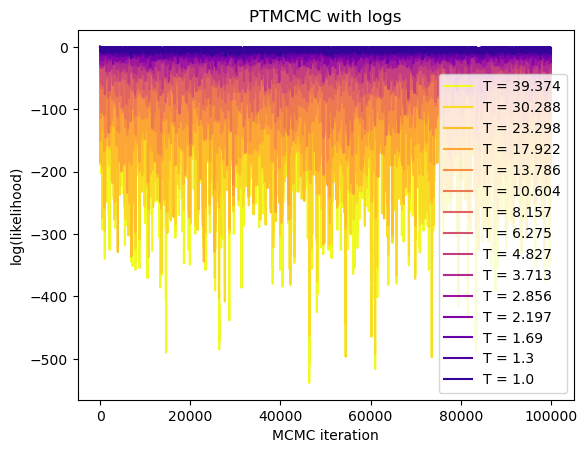

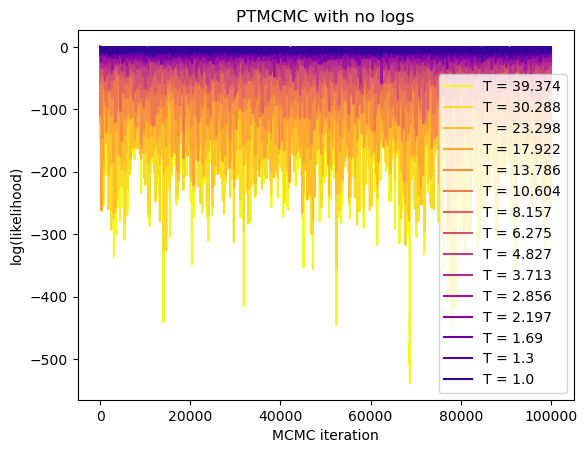

In [5]:
# plot likelihood values of chains (without temperature scaling)
chain_colors = list(reversed([plt.cm.plasma(i / num_chains) for i in range(1, num_chains + 1)]))

for j, (temp, color) in enumerate(zip(temp_ladder[::-1], chain_colors)):
    plt.plot(lnposts[::-1][j] * temp, color=color, label=f'T = {round(temp, 3)}')
plt.title('PTMCMC with logs')
plt.xlabel('MCMC iteration')
plt.ylabel('log(likelihood)')
plt.legend(loc='lower right')
plt.show()

for j, (temp, color) in enumerate(zip(temp_ladder_suppressed[::-1], chain_colors)):
    plt.plot(lnposts_suppressed[::-1][j] * temp, color=color, label=f'T = {round(temp, 3)}')
plt.title('PTMCMC with no logs')
plt.xlabel('MCMC iteration')
plt.ylabel('log(likelihood)')
plt.legend(loc='lower right')
plt.show()

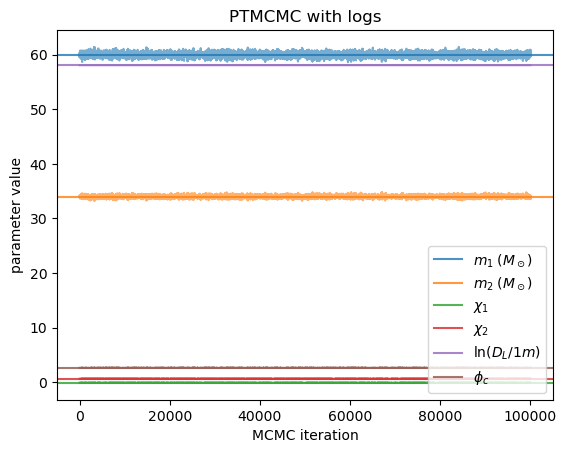

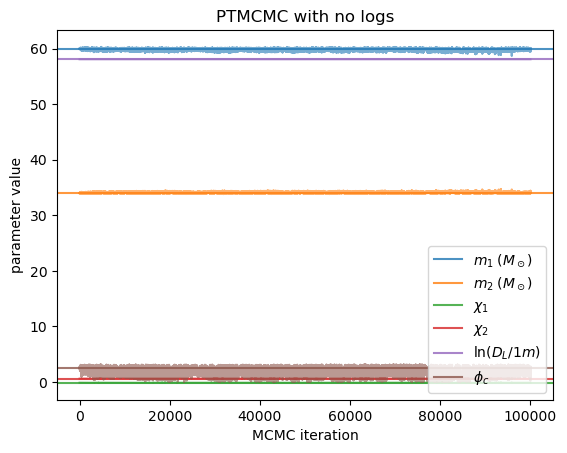

In [6]:
## trace plots for T = 1 chain
# logs
for i in range(wg.ndim):
    plt.plot(samples[0,:,i], color=f'C{i}', alpha=0.6)
    plt.axhline(d.x_inj[i], color=f'C{i}', alpha=0.8, label=wg.x_labels[i])
plt.title('PTMCMC with logs')
plt.xlabel('MCMC iteration')
plt.ylabel('parameter value')
plt.legend(loc='lower right')
plt.show()
# no logs
for i in range(wg.ndim):
    plt.plot(samples_suppressed[0,:,i], color=f'C{i}', alpha=0.6)
    plt.axhline(d.x_inj[i], color=f'C{i}', alpha=0.8, label=wg.x_labels[i])
plt.title('PTMCMC with no logs')
plt.xlabel('MCMC iteration')
plt.ylabel('parameter value')
plt.legend(loc='lower right')
plt.show()

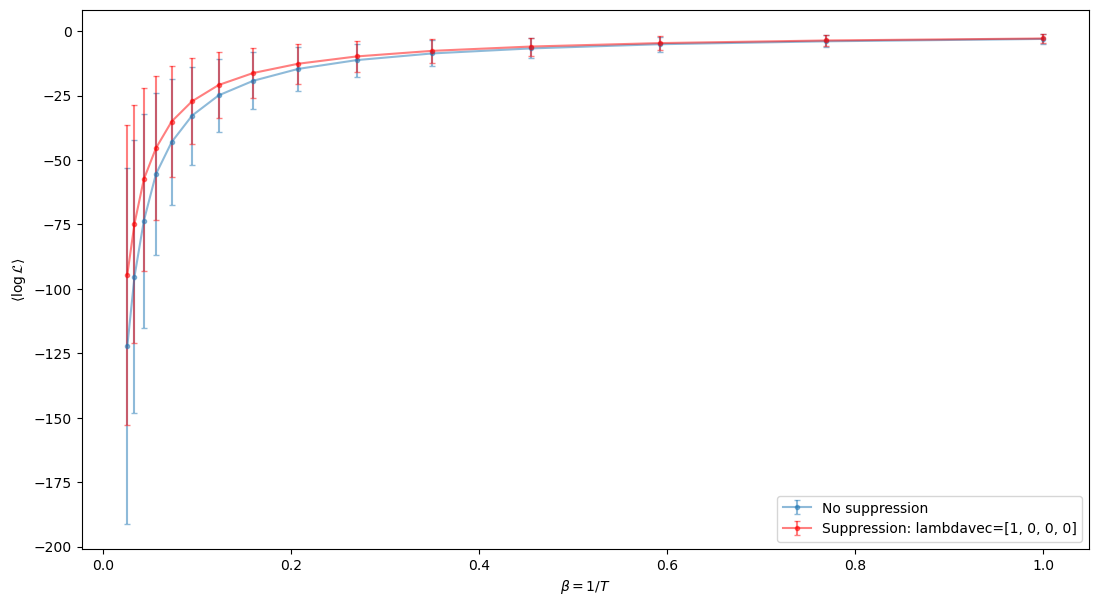

In [7]:
# average log-likelood over temperatures
burnin = num_samples // 5
avg_lnlikes = np.mean(lnposts[:, burnin:], axis=1) * temp_ladder
lnlike_stdevs = np.std(lnposts[:, burnin:], axis=1) * temp_ladder

avg_lnlikes_suppressed = np.mean(lnposts_suppressed[:, burnin:], axis=1) * temp_ladder
lnlike_stdevs_suppressed = np.std(lnposts_suppressed[:, burnin:], axis=1) * temp_ladder

betas = 1. / temp_ladder

plt.figure(figsize=(13,7))

# logs (default)
plt.errorbar(betas, avg_lnlikes, yerr=lnlike_stdevs, marker='.', capsize=2, alpha=0.5, label='No suppression')
# no logs
plt.errorbar(betas, avg_lnlikes_suppressed, yerr=lnlike_stdevs_suppressed, marker='.', capsize=2, color='r', alpha=0.5, label='Suppression: lambdavec=[{}, {}, {}, {}]'.format(d.lambda15, d.lambda25, d.lambda3, d.lambda35))


plt.xlabel(r'$\beta = 1 / T$')
plt.ylabel(r'$\langle\log\mathcal{L}\rangle$')
plt.legend(loc='lower right')
plt.show()

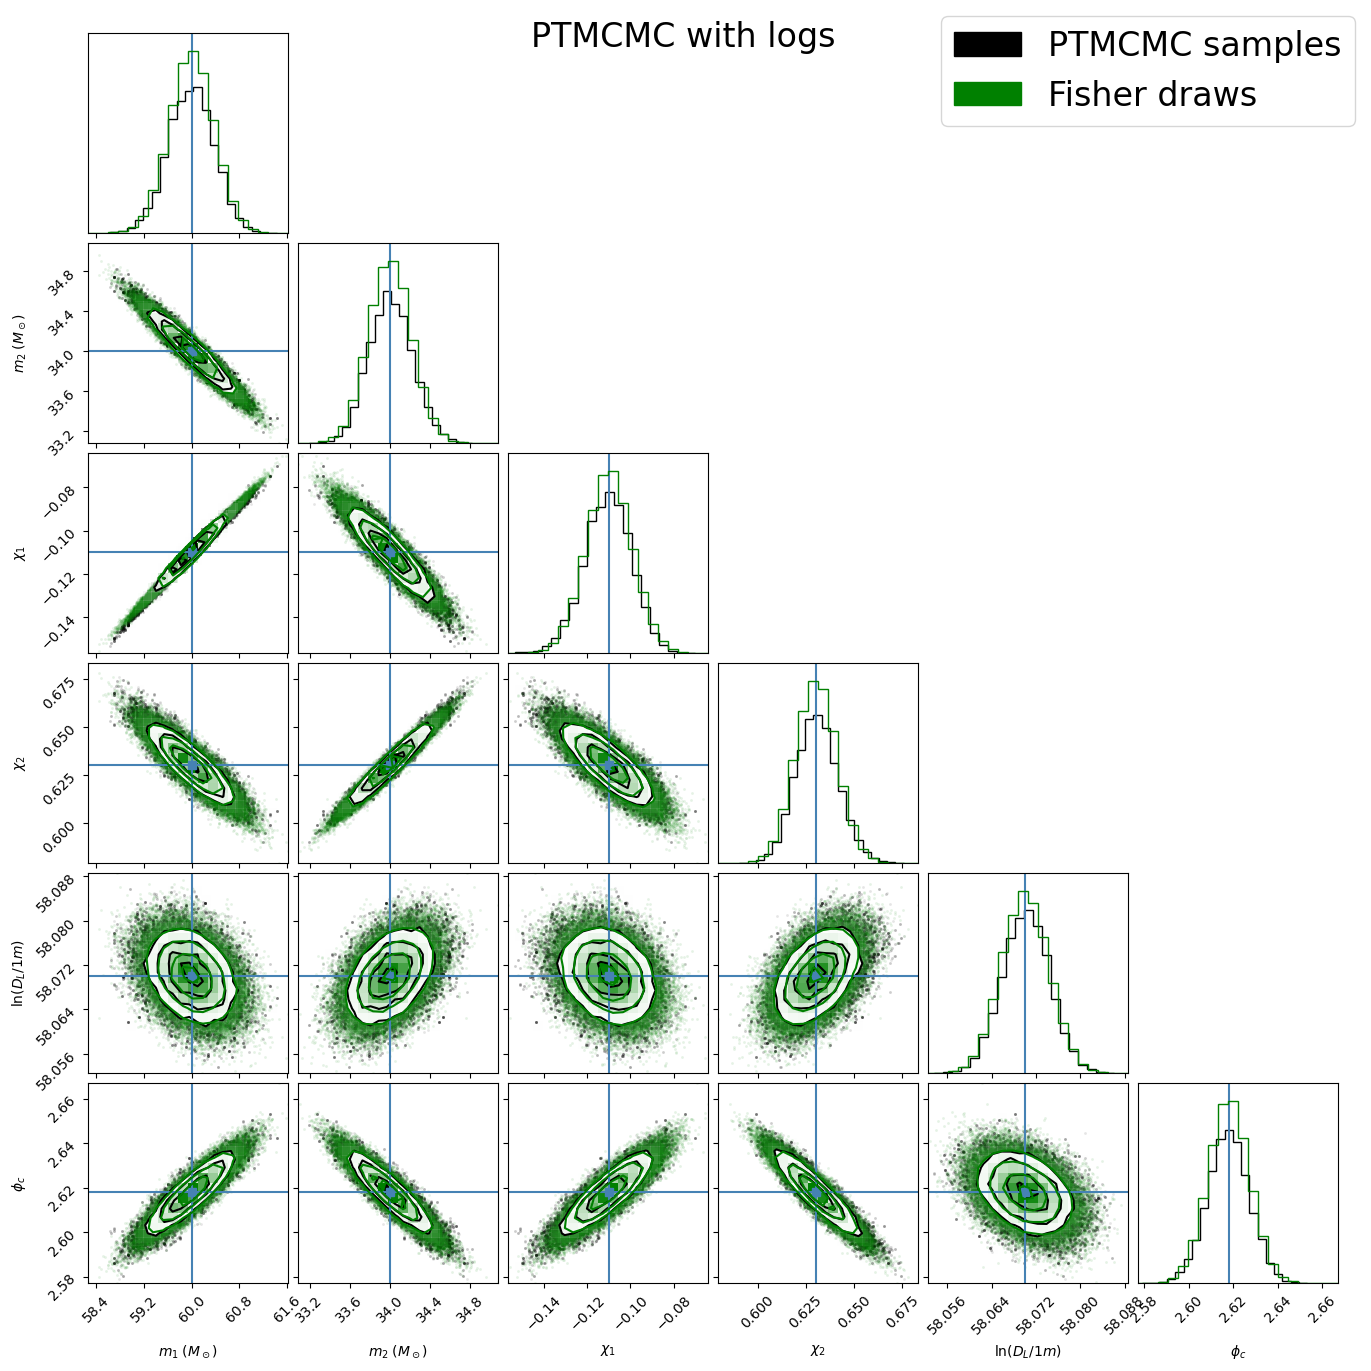

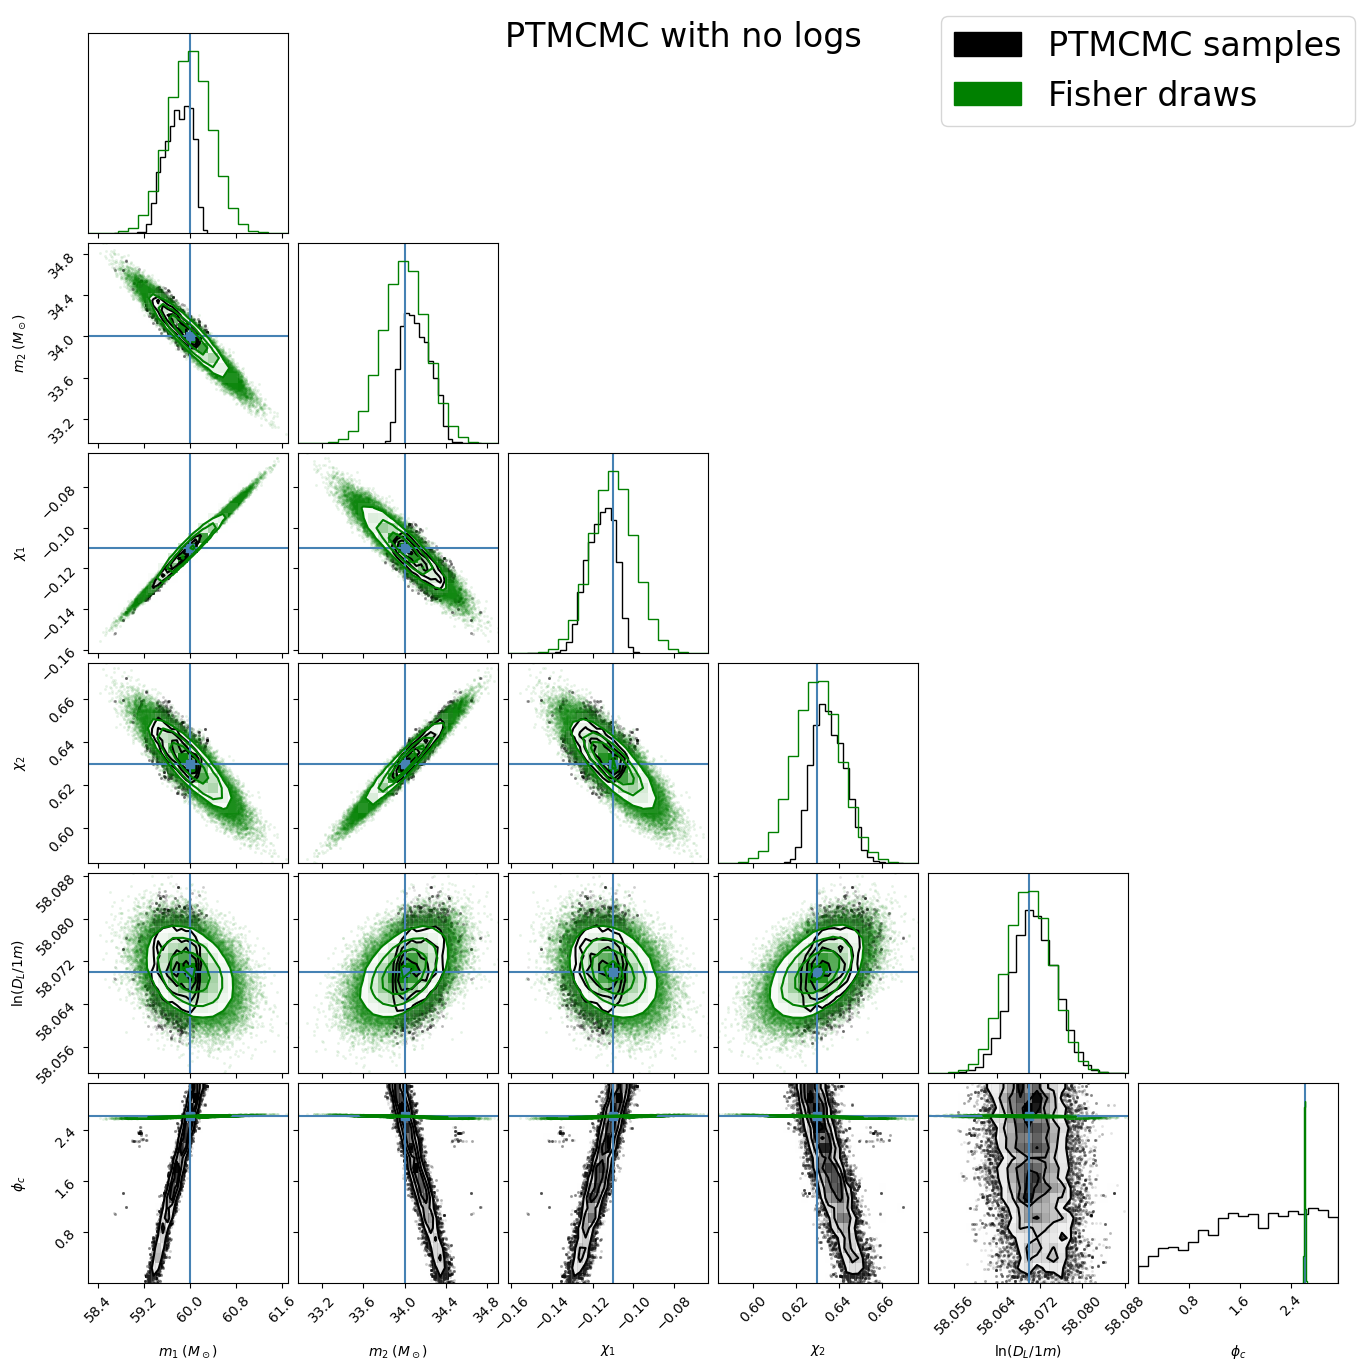

In [8]:
### corner plot

################################## incorp lambda suppression into Fisher stuff

## logs
fig = corner(samples[0, burnin:],
             truths=d.x_inj,
             labels=wg.x_labels)

# also plot samples from multi-variate Gaussian
# which has a covariance estimated from the inverse Fisher
Fisher_samples = multivariate_normal(d.x_inj, np.linalg.inv(l.get_Fisher(d.x_inj))).rvs(num_samples - burnin)
corner(Fisher_samples, color='green', fig=fig)

## no logs
fig_suppressed = corner(samples_suppressed[0, burnin:],
                        truths=d.x_inj,
                        labels=wg.x_labels)

# also plot samples from multi-variate Gaussian
# which has a covariance estimated from the inverse Fisher
Fisher_samples = multivariate_normal(d.x_inj, np.linalg.inv(l.get_Fisher(d.x_inj))).rvs(num_samples - burnin)
corner(Fisher_samples, color='green', fig=fig_suppressed)



black_patch = mpatches.Patch(color='black', label='PTMCMC samples')
green_patch = mpatches.Patch(color='green', label='Fisher draws')
handles, labels = plt.gca().get_legend_handles_labels()
handles += [black_patch, green_patch]
fig.legend(handles=handles, loc='upper right', fontsize=24)
fig_suppressed.legend(handles=handles, loc='upper right', fontsize=24)

fig.suptitle('PTMCMC with logs', fontsize=24)
fig_suppressed.suptitle('PTMCMC with no logs', fontsize=24)
plt.show()

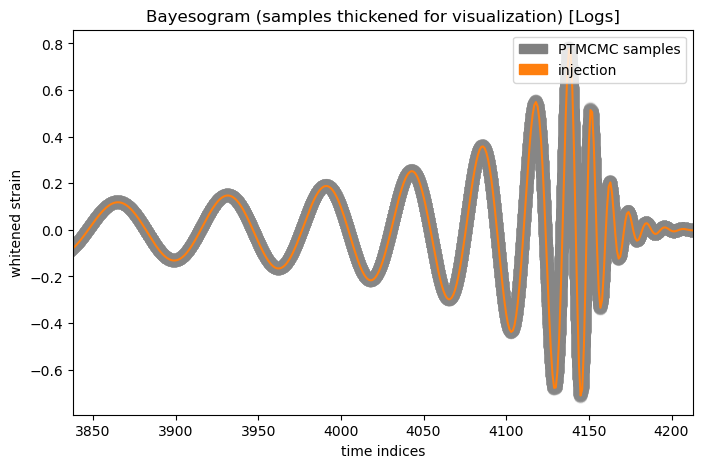

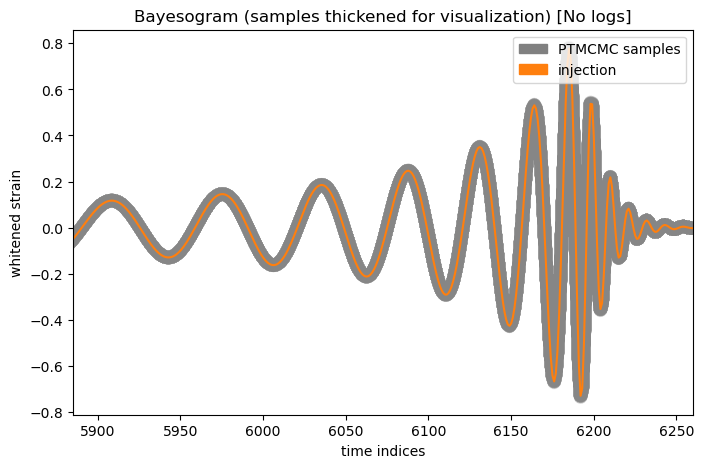

In [9]:
### Bayesogram

## logs
npad = int(wg.f[0] / wg.df)
whitened_FD_waveform_inj = np.pad(d.data_FD_waveform / l.sqrtS, (npad, 0))
TD_waveform_inj = np.fft.irfft(whitened_FD_waveform_inj)
roll_amt = TD_waveform_inj.shape[0] // 2
TD_waveform_inj = np.roll(TD_waveform_inj, roll_amt)

num_draws = 100
draw_ndxs = np.random.choice(np.arange(burnin, num_samples), num_draws)
plt.figure(figsize=(8, 5))
for ndx in draw_ndxs:
    whitened_FD_waveform = np.pad(wg.FD_waveform(samples[0, ndx]) / l.sqrtS, (npad, 0))
    TD_waveform = np.fft.irfft(whitened_FD_waveform)
    TD_waveform = np.roll(TD_waveform, roll_amt)
    plt.plot(TD_waveform, color='grey', alpha=1.0/num_draws, lw=10)
plt.plot(TD_waveform_inj, color='C1')
grey_patch = mpatches.Patch(color='grey', label='PTMCMC samples')
orange_patch = mpatches.Patch(color='C1', label='injection')
handles, labels = plt.gca().get_legend_handles_labels()
handles += [grey_patch, orange_patch]
plt.legend(handles=handles, loc='upper right')
plt.xlim(np.argmax(TD_waveform) - 300, np.argmax(TD_waveform) + 75)
plt.xlabel('time indices')
plt.ylabel('whitened strain')
plt.title('Bayesogram (samples thickened for visualization) [Logs]')
plt.show()

## no logs
#npad = int(wg.f[0] / wg.df)
whitened_FD_waveform_inj_suppressed = np.pad(d.data_FD_waveform_suppressed / l.sqrtS, (npad, 0))
TD_waveform_inj_suppressed = np.fft.irfft(whitened_FD_waveform_inj_suppressed)
roll_amt_suppressed = TD_waveform_inj_suppressed.shape[0] // 2
TD_waveform_inj_suppressed = np.roll(TD_waveform_inj_suppressed, roll_amt_suppressed)

#num_draws = 100
#draw_ndxs = np.random.choice(np.arange(burnin, num_samples), num_draws)
plt.figure(figsize=(8, 5))
for ndx in draw_ndxs:
    whitened_FD_waveform_suppressed = np.pad(wg.FD_waveform(samples_suppressed[0, ndx], d.lambda15, d.lambda25, d.lambda3, d.lambda35) / l.sqrtS, (npad, 0))
    TD_waveform_suppressed = np.fft.irfft(whitened_FD_waveform_suppressed)
    TD_waveform_suppressed = np.roll(TD_waveform_suppressed, roll_amt_suppressed)
    plt.plot(TD_waveform_suppressed, color='grey', alpha=1.0/num_draws, lw=10)
plt.plot(TD_waveform_inj_suppressed, color='C1')
#grey_patch = mpatches.Patch(color='grey', label='PTMCMC samples')
#orange_patch = mpatches.Patch(color='C1', label='injection')
#handles, labels = plt.gca().get_legend_handles_labels()
#handles += [grey_patch, orange_patch]
plt.legend(handles=handles, loc='upper right')
plt.xlim(np.argmax(TD_waveform_suppressed) - 300, np.argmax(TD_waveform_suppressed) + 75)
plt.xlabel('time indices')
plt.ylabel('whitened strain')
plt.title('Bayesogram (samples thickened for visualization) [No logs]')
plt.show()